# Assignment 5: Reducing High-Dimensional Data with PCA

**Student Name:** Jemiran Hunter

**Date:** 3/1/2026

---

## Assignment Overview

You've joined the data science team at FitTrack Analytics, a company that develops fall detection systems for elderly care facilities. Their wearable devices capture 561 sensor features from accelerometer and gyroscope readings. Your task: use Principal Component Analysis (PCA) to compress this high-dimensional data into something you can visualize, understand, and build reliable models from.

---

## Step 1: Import Libraries and Load Data

In [1]:
pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [4]:
# Load the Human Activity Recognition dataset
# TODO Load train.csv and test.csv from the data folder
train_df = pd.read_csv(r"C:\Users\Ekaza-BTG PC4\Dimensionality_Reduction_Techniques\data\train.csv")  # Replace with pd.read_csv()
test_df = pd.read_csv(r"C:\Users\Ekaza-BTG PC4\Dimensionality_Reduction_Techniques\data\test.csv")   # Replace with pd.read_csv()

df = train_df.head()
print("\n" + "="*80)
print("CHECKPOINT: Dataset loaded successfully")
print(f"Training set shape: {train_df.shape if train_df is not None else 'Not loaded'}")
print(f"Test set shape: {test_df.shape if test_df is not None else 'Not loaded'}")
print("First 5 rows of the training set:")
print(df if train_df is not None else "Training set not loaded")
print("="*80)

# TODO Separate features from labels
# Create X_train, y_train, X_test, y_test
# The 'Activity' column contains the labels
X_train = train_df.drop('Activity', axis=1)
y_train = train_df['Activity']
X_test = test_df.drop('Activity', axis=1)
y_test = test_df['Activity']

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape if X_train is not None else 'Not loaded'}")
print(f"Test set shape: {X_test.shape if X_test is not None else 'Not loaded'}")
print(f"Number of features: {X_train.shape[1] if X_train is not None else 'N/A'}")
print(f"Unique activities: {y_train.nunique() if y_train is not None else 'N/A'}")
print("="*80)


CHECKPOINT: Dataset loaded successfully
Training set shape: (7352, 563)
Test set shape: (2947, 563)
First 5 rows of the training set:
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   

---
## Step 2: Experience the Problem - Try to Understand 561 Dimensions

### Attempt Visualization with 2 Features

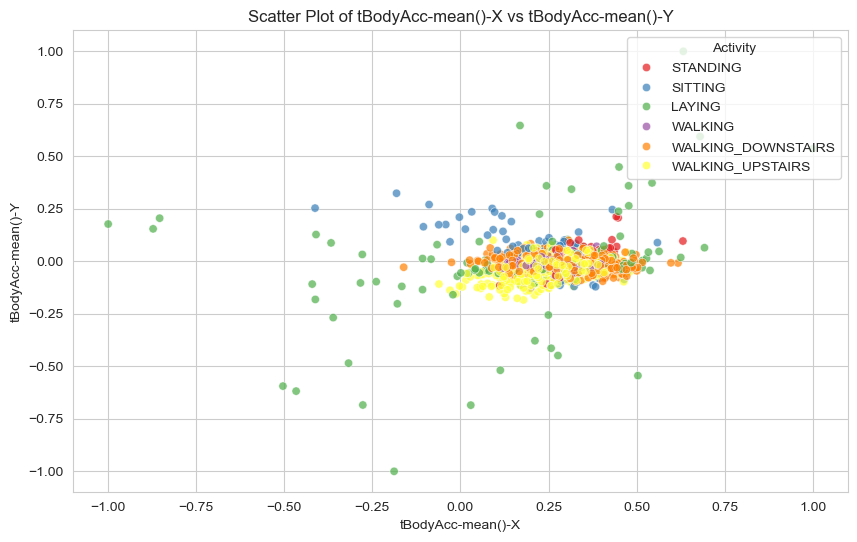

In [6]:
# TODO Create a scatter plot using any 2 of the 561 features
# Color points by activity type
# Can you see clear patterns separating the six activities?

# Label names for the 10 classes
label_names = {0: 'tBodyAcc-mean()-X', 1: 'tBodyAcc-mean()-Y', 2: 'tBodyAcc-mean()-Z', 3: 'tBodyAcc-std()-X', 4: 'tBodyAcc-std()-Y',
               5: 'tBodyAcc-std()-Z', 6: 'tBodyAcc-mad()-X', 7: 'tBodyAcc-mad()-Y', 8: 'tBodyAcc-mad()-Z', 9: 'tBodyAcc-max()-X'}

# Select two features for the scatter plot
feature_x = 'tBodyAcc-mean()-X'
feature_y = 'tBodyAcc-mean()-Y'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_train, x=feature_x, y=feature_y, hue=y_train, palette='Set1', alpha=0.7)
plt.title(f'Scatter Plot of {feature_x} vs {feature_y}')
plt.xlabel(label_names.get(X_train.columns.get_loc(feature_x), feature_x))
plt.ylabel(label_names.get(X_train.columns.get_loc(feature_y), feature_y))
plt.legend(title='Activity', loc='upper right')
plt.show()


### Check Feature Correlations

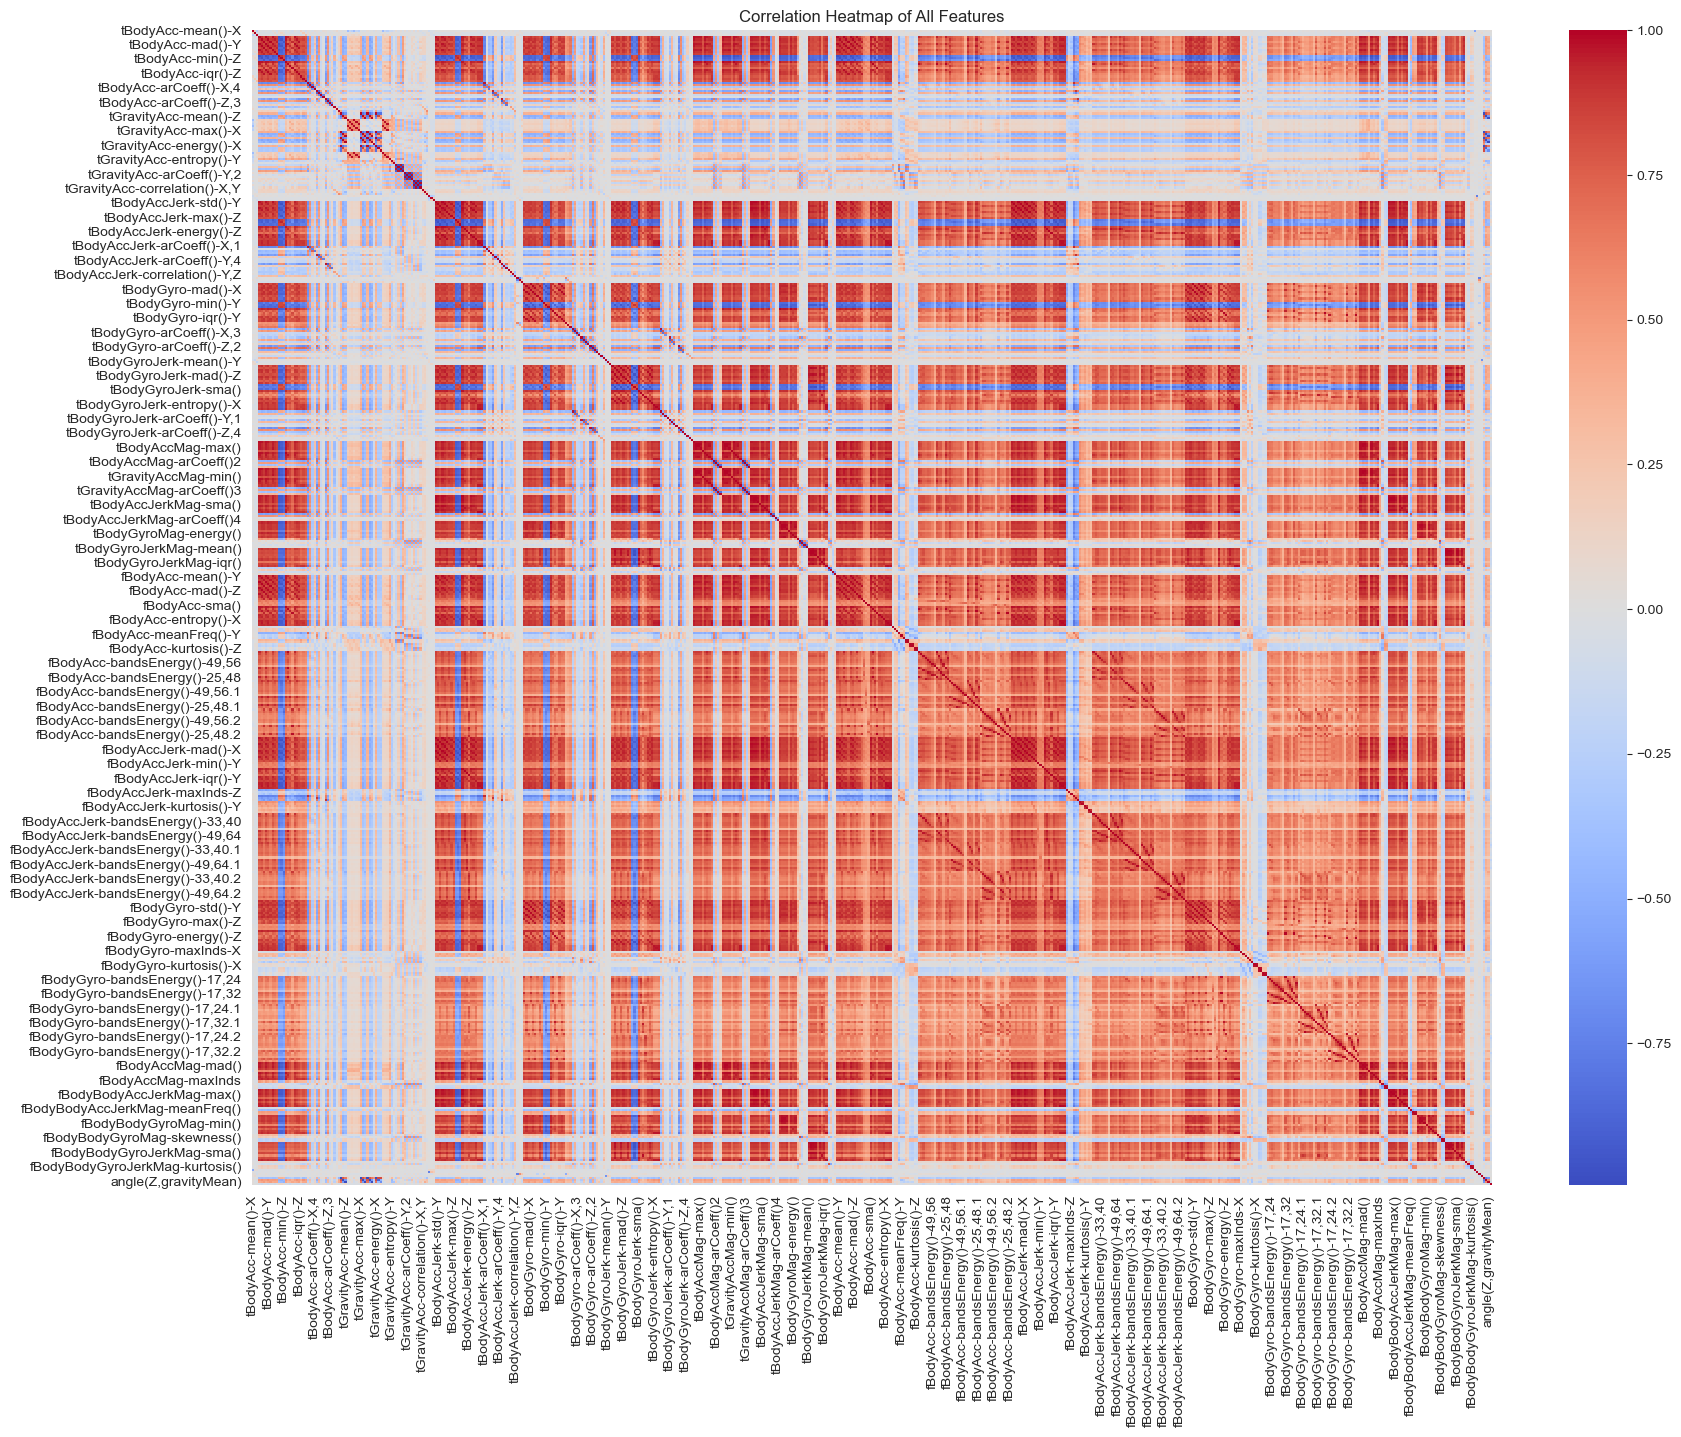

In [7]:
# TODO Create a correlation heatmap of all 561 features
# Is it readable? Can you identify redundant features?

plt.figure(figsize=(20, 15))
sns.heatmap(X_train.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of All Features')
plt.show()


### Train Baseline Model

In [8]:
start_time = time.time()

# TODO Train a RandomForestClassifier with n_estimators=100, random_state=42
# Your code here
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_model.fit(X_train, y_train)

# Calculates baseline training time
baseline_time = time.time() - start_time

# TODO Calculate accuracy on test set
baseline_accuracy = baseline_model.score(X_test, y_test)

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print(f"Number of features: {X_train.shape[1]}")
print(f"Accuracy: {baseline_accuracy if baseline_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)


BASELINE MODEL RESULTS
Number of features: 562
Accuracy: 0.9267051238547676
Training time: 34.08 seconds


### Reflection on High-Dimensional Data
In the Markdown cell below this step, write 2-3 sentences responding to the following question: 
- What problems did you encounter trying to understand 561 dimensions?


The scatterplot was clear but all the data points cluttered around the same area which is misleading considering 561 dimensions. The heatmap was very confusing and difficult to interpet or pick up any significant infomration. It tok this baseline model about 34 seconds to train. 

---
## Step 3: Apply PCA to Visualize in 2D and 3D

### Standardize Features

In [9]:
# TODO Use StandardScaler to normalize all 562 features
# Fit on training data, transform both training and test data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Replace with scaled training data using scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # Replace with scaled test data using scaler.transform(X_test)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Scaled training shape: {X_train_scaled.shape if X_train_scaled is not None else 'Not scaled'}")
print("="*80)


CHECKPOINT: Features Standardized
Scaled training shape: (7352, 562)


### Apply PCA for 2 Components

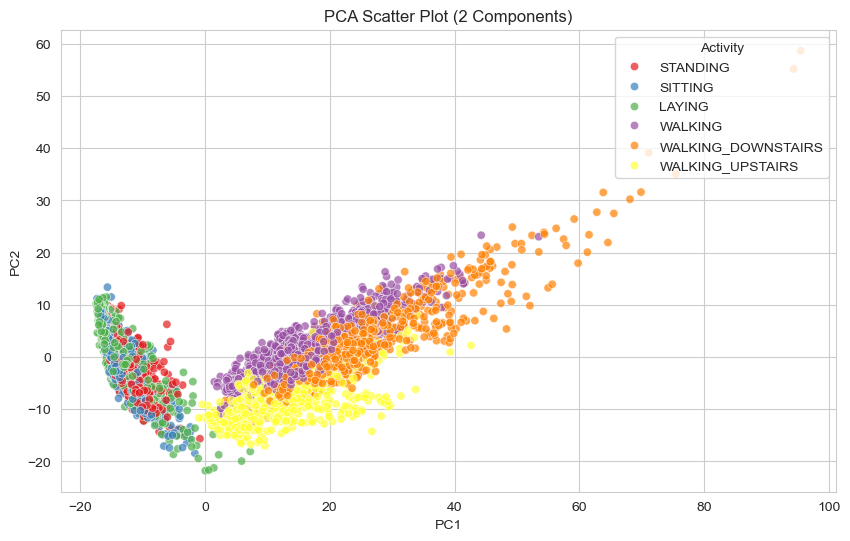

In [10]:
# TODO Use PCA(n_components=2)
# Fit on standardized training data, transform both sets

pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data using pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d = pca_2d.transform(X_test_scaled)   # Replace with PCA-transformed test data using pca_2d.transform(X_test_scaled)

# TODO Create scatter plot using the 2 principal components
# Color by activity type, add title, axis labels (PC1, PC2), and legend

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_pca_2d[:, 0], y=X_train_pca_2d[:, 1], hue=y_train, palette='Set1', alpha=0.7)
plt.title('PCA Scatter Plot (2 Components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Activity', loc='upper right')
plt.show()


### Apply PCA for 3 Components

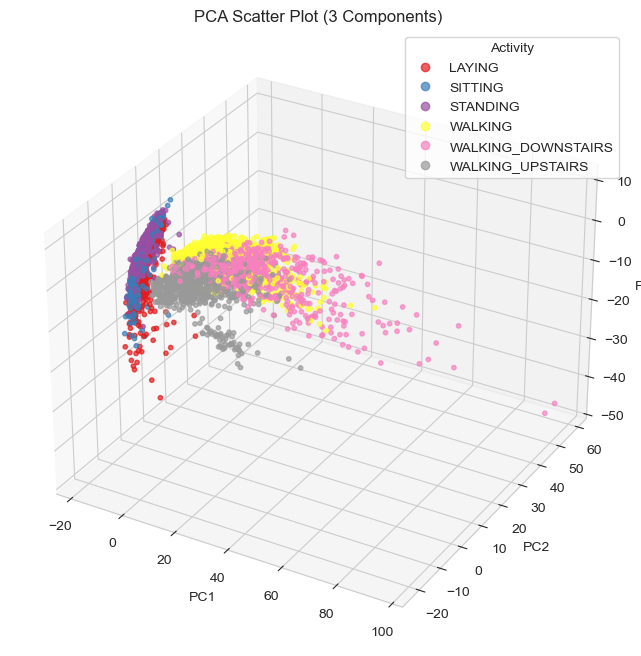

In [12]:
# TODO Use PCA(n_components=3)
# Fit on standardized training data, transform both sets

pca_3d = PCA(n_components=3)
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data using pca_3d.fit_transform(X_train_scaled)
X_test_pca_3d = pca_3d.transform(X_test_scaled)   # Replace with PCA-transformed test data using pca_3d.transform(X_test_scaled)

# TODO Create 3D scatter plot using the 3 principal components
# Use mpl_toolkits.mplot3d.Axes3D
# Color by activity type

label_names = y_train.astype('category').cat.categories
label_codes = y_train.astype('category').cat.codes

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_train_pca_3d[:, 0],
    X_train_pca_3d[:, 1],
    X_train_pca_3d[:, 2],
    c=label_codes,
    cmap='Set1',
    alpha=0.7,
    s=10
    )
ax.set_title('PCA Scatter Plot (3 Components)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

handles, _ = scatter.legend_elements()
ax.legend(handles, label_names, title='Activity', loc='upper right')
plt.show()


### Reflection on PCA Visualization
In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- What activity patterns can you now see? 
- Which activities cluster together?


Laying, sitting, and standing cluster together as well as walking and walking downstairs. Walking and walking downstrairs seem to have the majority of the data points which could be good indicators to use for a predictive model or draw more insights from. Laying and Walking downstairs show a lot of difference between one another, which seems as though there would not be much connection between the two. 

---
## Step 4: Determine Optimal Number of Components Using Explained Variance

### Create Scree Plot

EXPLAINED VARIANCE BY COMPONENT
Total components available: 100

PC1 explains: 50.69% of variance
PC2 explains: 6.57% of variance
PC3 explains: 2.80% of variance
PC4 explains: 2.50% of variance
PC5 explains: 1.88% of variance
...
PC50 explains: 0.23% of variance
PC100 explains: 0.10% of variance


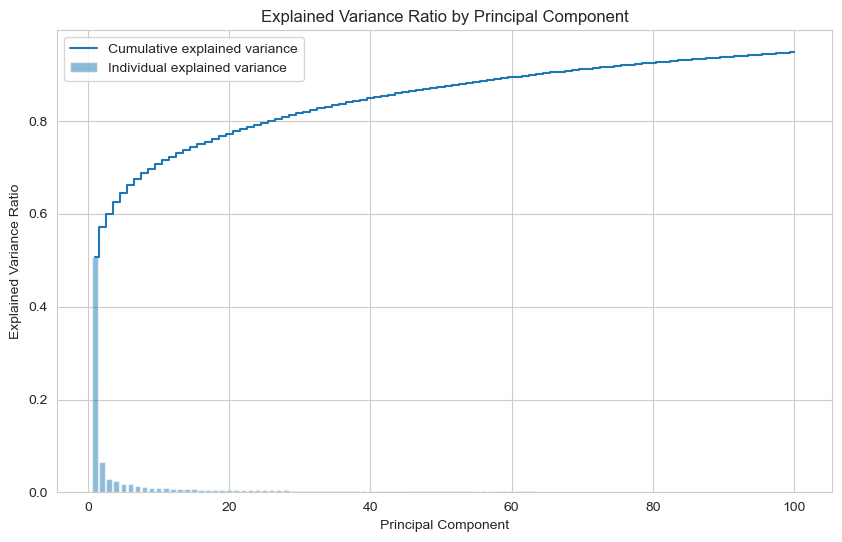

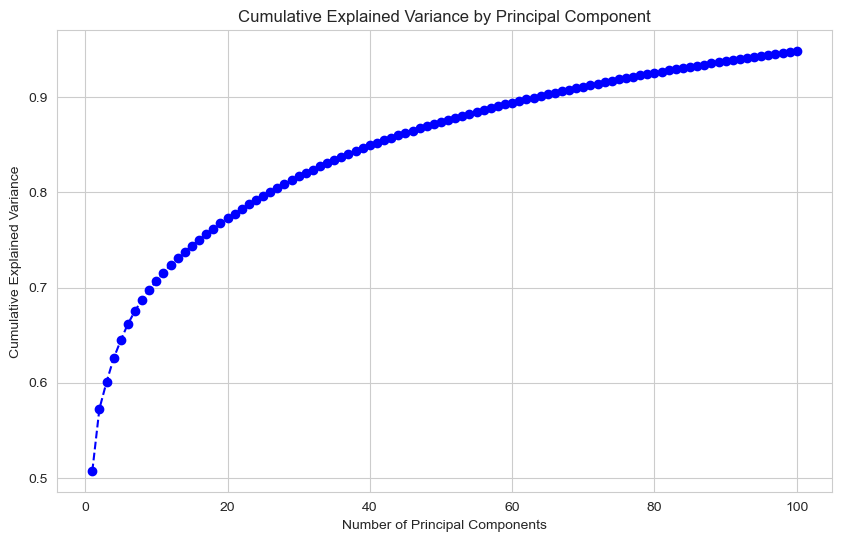

In [17]:
# Fit PCA(n_components=100) to standardized training data
pca_full = PCA(n_components=100)
pca_full.fit(X_train_scaled)

# Your code here
explained_variance_ratio = pca_full.explained_variance_ratio_
n_components_total = len(explained_variance_ratio)
cumulative_variance = np.cumsum(explained_variance_ratio)

print("="*80)
print("EXPLAINED VARIANCE BY COMPONENT")
print("="*80)
print(f"Total components available: {n_components_total}")
print(f"\nPC1 explains: {explained_variance_ratio[0]:.2%} of variance")
print(f"PC2 explains: {explained_variance_ratio[1]:.2%} of variance")
print(f"PC3 explains: {explained_variance_ratio[2]:.2%} of variance")
print(f"PC4 explains: {explained_variance_ratio[3]:.2%} of variance")
print(f"PC5 explains: {explained_variance_ratio[4]:.2%} of variance")
print("...")
print(f"PC50 explains: {explained_variance_ratio[49]:.2%} of variance")
print(f"PC100 explains: {explained_variance_ratio[99]:.2%} of variance")
print("="*80)


# TODO Plot explained variance ratio for each component
# Use pca_full.explained_variance_ratio_ to get the ratios
# Use np.cumsum() to compute cumulative variance 

plt.figure(figsize=(10, 6))
plt.bar(range(1, n_components_total + 1), explained_variance_ratio, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, n_components_total + 1), cumulative_variance, where='mid', label='Cumulative explained variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component')
plt.legend(loc='best')
plt.show()

# TODO Plot cumulative explained variance

plt.figure(figsize=(10, 6))
plt.plot(range(1, n_components_total + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Principal Component')
plt.grid(True)
plt.show()


### Analyze the Elbow

In [18]:
# TODO Identify how many components capture 75%, 80%, and variance
# You can use pca_full.explained_variance_ratio_ and np.cumsum()

pca_full.explained_variance_ratio_ 
np.cumsum(explained_variance_ratio)


components_75 = np.argmax(cumulative_variance >= 0.75) + 1  # Replace with number of components for 75%
components_80 = np.argmax(cumulative_variance >= 0.80) + 1  # Replace with number of components for 80%
components_90 = np.argmax(cumulative_variance >= 0.90) + 1  # Replace with number of components for 90%

print("\n" + "="*80)
print("EXPLAINED VARIANCE ANALYSIS")
print(f"Components for 75% variance: {components_75}")
print(f"Components for 80% variance: {components_80}")
print(f"Components for 90% variance: {components_90}")
print("="*80)


EXPLAINED VARIANCE ANALYSIS
Components for 75% variance: 16
Components for 80% variance: 26
Components for 90% variance: 64


### Select Optimal Components

In [19]:
# TODO Set your chosen optimal number of components
optimal_components = components_80  # Replace with your chosen value (components_75, components_80, or components_90)

print(f"Chosen number of components: {optimal_components}")

Chosen number of components: 26


In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- How many components did you select based on the elbow? 
- What percentage of variance does this capture? 
- What's the tradeoff?


I chose 26 components as it descibes 80% of the variance. I felt like this was right in the sweet spot. The tradeoff is lower amount of components that contribute to the variance but also limits the amount of components that could be making information noisy. 

---
## Step 5: Compare Model Performance - Original vs PCA Features

### Transform Data with Optimal Components

In [20]:
# TODO Apply PCA with your optimal number of components
# Fit on standardized training data, transform both sets

pca_optimal = PCA(n_components=optimal_components)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data
X_test_pca = pca_optimal.transform(X_test_scaled)   # Replace with PCA-transformed test data

print("\n" + "="*80)
print("CHECKPOINT: Data Transformed with Optimal Components")
print(f"New feature dimensions: {X_train_pca.shape if X_train_pca is not None else 'Not transformed'}")
print("="*80)


CHECKPOINT: Data Transformed with Optimal Components
New feature dimensions: (7352, 26)


### Train PCA Model

In [21]:
# To measure training time
start_time = time.time()

# TODO Train RandomForestClassifier with same parameters
# Use n_estimators=100, random_state=42
# Use X_train_pca and y_train
pca_model = RandomForestClassifier(n_estimators=100, random_state=42)
pca_model.fit(X_train_pca, y_train)

# TODO Calculate accuracy on test set
pca_accuracy = pca_model.score(X_test_pca, y_test)

# Record: accuracy, training time, number of features
pca_time = time.time() - start_time
print("\n" + "="*80)
print("PCA MODEL RESULTS")
print(f"Number of features: {optimal_components}")
print(f"Accuracy: {pca_accuracy if pca_accuracy else 'Not calculated'}")
print(f"Training time: {pca_time:.2f} seconds")
print("="*80)


PCA MODEL RESULTS
Number of features: 26
Accuracy: 0.8635900916185952
Training time: 10.85 seconds


### Create Comparison Table

In [22]:
# Create comparison table showing:
# - Number of features
# - Accuracy
# - Training time

comparison_df = pd.DataFrame({
    'Model': ['Baseline (All Features)', 'PCA Model'],
    'Features': [561, optimal_components],
    'Accuracy': [baseline_accuracy, pca_accuracy],
    'Training Time (s)': [baseline_time, pca_time]
})

# TODO Calculate speedup factor
speedup = baseline_time / pca_time  # Replace with baseline_time / pca_time

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print(f"\nSpeedup factor: {speedup:.2f}x" if speedup else "\nSpeedup not calculated")
print("="*80)


MODEL COMPARISON
                  Model  Features  Accuracy  Training Time (s)
Baseline (All Features)       561  0.926705          34.076786
              PCA Model        26  0.863590          10.845912

Speedup factor: 3.14x


### Final Analysis

In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- Did PCA improve or hurt accuracy? 
- How much faster was training? 
- When would you recommend using PCA?


The PCA only reduced the accuracy by 6 points. I wouldn't consider that hurt a major way. The PCA model is 3x faster than the baseline model. The PCA model was way easier to read and understand. I didn't lose anything other than 6 points in accuracy. I would recommend using PCA when there are way to many dimensions and is extremely difficult to make sense of the data. 

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline model with metrics recorded
   - 2D and 3D PCA visualizations
   - Scree plot with explained variance
   - Optimal component selection with justification
   - Model comparison table
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed PCA dimensionality reduction assignment'
git push
```

Submit your GitHub repository link on the course platform.